In [1]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("cardio_train.csv", sep=';')
df
# outlier handling

# 1. Checked and handled missing values

In [ ]:
df.isna().sum()

# 2. Removed duplicate rows

In [ ]:
df.duplicated()

In [ ]:
df.duplicated().sum()

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

# 3. Fixed incorrect data types

In [ ]:
df.dtypes

In [ ]:
df['age'] = df['age']/365;

In [ ]:
df['age']

# 4. Checked and treated outliers

In [ ]:
# Outliers are mainly present in

# height
# weight
# ap_hi
# ap_lo

df[["height","weight","ap_hi","ap_lo"]].describe()

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column="ap_hi")

plt.show()

In [ ]:
df.boxplot(column="ap_lo")

plt.show()

In [ ]:
df.boxplot(column="height")

plt.show()

In [ ]:
df.boxplot(column="weight")

plt.show()

# 5. Visualize numeric columns

In [ ]:

df["age"].hist()
plt.show()

In [ ]:
df["weight"].hist()
plt.show()

In [ ]:
df["height"].hist()
plt.show()

In [ ]:
df["ap_hi"].hist()
plt.show()

# 6. Visualize categorical columns

In [ ]:
df["gender"].value_counts()

In [ ]:
df["gender"].value_counts().plot(kind="bar")
plt.show()


In [ ]:
df["cardio"].value_counts().plot(kind="bar")
plt.show()

In [ ]:
df["cardio"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

columns_to_scale = ["age", "height", "weight", "ap_hi", "ap_lo"]

scaler = StandardScaler()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [ ]:
X_train.head()

In [ ]:
print(X_train[columns_to_scale].mean())

In [ ]:
print(X_train[columns_to_scale].std())

In [ ]:
print(df[columns_to_scale].head())

In [ ]:
df['BMI']= df['weight']/((df['height']/100)**2)

df['BMI']

In [ ]:
df['bmi_category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, float('inf')], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'], right=False)

In [ ]:
df['bmi_category']

In [ ]:
print(df.duplicated().sum())

In [ ]:
df=df.drop_duplicates()

In [ ]:
print(df.duplicated().sum())

# 7. Final model-ready preprocessing


In [ ]:
# Convert age from days to years, matching the model input used by the application.
df = df.copy()
df['age'] = (df['age'] / 365).astype(int)

# BMI is already calculated above. Remove only the categorical BMI helper column.
df = df.drop(columns=['bmi_category'], errors='ignore')

# Remove the identifier column before creating the final feature matrix.
df = df.drop(columns=['id'], errors='ignore')

X = df.drop(columns=['cardio'])
y = df['cardio']


In [ ]:
# Final feature names used by the prediction model
print('Feature columns:')
print(X.columns.tolist())
print('\nNumber of features:', X.shape[1])


In [ ]:
df.columns

In [ ]:
# Train/test split for the final model-ready dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Inputs and target
X = df.drop(columns="cardio")
y = df["cardio"]

# Split raw data; do not scale it manually
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Pipeline: it scales data first, then trains the model
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train pipeline
model_pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = model_pipeline.predict(X_test)

In [ ]:
import joblib
from pathlib import Path

model_file = Path(
    r"C:\Users\ASUS\OneDrive\Desktop\Sem5\ML\Project"
) / "cardiovascular_logistic_regression_pipeline.pkl"

joblib.dump(model_pipeline, model_file)

print("Saved successfully:", model_file)
print("File exists:", model_file.exists())

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
import subprocess

subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "show",
    "scikit-learn"
])

In [ ]:
import joblib

model = joblib.load("cardiovascular_logistic_regression.pkl")

print(type(model))
print(model.feature_names_in_)

In [ ]:
import sys
import sklearn

print("Python:", sys.executable)
print("scikit-learn:", sklearn.__version__)

In [ ]:
import os

print(os.path.abspath("cardiovascular_logistic_regression.pkl"))

In [2]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Load fresh dataset
df = pd.read_csv("cardio_train.csv", sep=";")

# Remove ID before creating X
df = df.drop(columns="id")

# Convert age from days to years
df["age"] = (df["age"] / 365.25).astype(int)

# Create BMI
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

# Inputs and target
X = df.drop(columns="cardio")
y = df["cardio"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaler and model together
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
model_pipeline.fit(X_train, y_train)

# Confirm input features
print(model_pipeline.feature_names_in_)

['age' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc'
 'smoke' 'alco' 'active' 'BMI']


In [4]:
joblib.dump(
    model_pipeline,
    r"C:\Users\ASUS\OneDrive\Desktop\Sem5\ML\Project\cardiovascular_logistic_regression_pipeline.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Model Evaluation

# The trained Logistic Regression model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict test data
y_pred = model_pipeline.predict(X_test)
# Calculate evalution metrics
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1_score = f1_score(y_test,y_pred)

# Display Result

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1-Score :", round(f1_score* 100, 2), "%")

Accuracy : 71.39 %
Precision: 73.16 %
Recall   : 67.51 %
F1-Score : 70.22 %


In [6]:
# Confusion Matrix

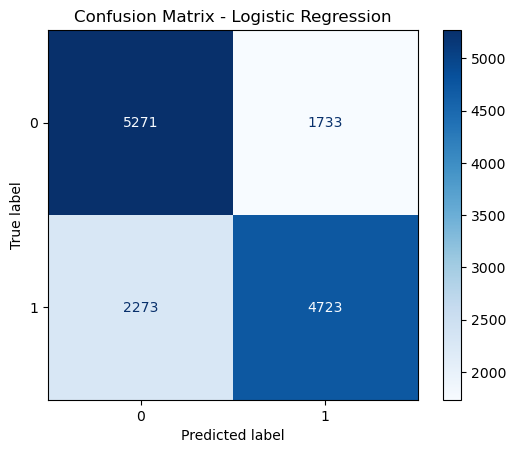

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 2. Check Overfitting / Underfitting [BOTH]

Compare **Train Accuracy** vs **Test Accuracy** to diagnose model fit:
- Train score >> Test score → **Overfitting**
- Both scores low → **Underfitting**
- Train ≈ Test scores → **Good Fit ✅**

In [8]:
from sklearn.metrics import accuracy_score

# Predict on TRAIN set (data the model SAW during training)
y_train_pred = model_pipeline.predict(X_train)

# Predict on TEST set (data the model NEVER saw)
y_test_pred = model_pipeline.predict(X_test)

# Calculate Train and Test accuracy
train_score = accuracy_score(y_train, y_train_pred) * 100
test_score  = accuracy_score(y_test,  y_test_pred)  * 100

print(f"Train Accuracy : {train_score:.2f}%")
print(f"Test  Accuracy : {test_score:.2f}%")
print(f"Difference     : {abs(train_score - test_score):.2f}%")
print()

# Interpret the result
if train_score - test_score > 5:
    print("Warning: OVERFITTING - Train score is much higher than Test score.")
elif train_score < 70 and test_score < 70:
    print("Warning: UNDERFITTING - Both Train and Test scores are low.")
else:
    print("GOOD FIT: Train and Test scores are close to each other.")

Train Accuracy : 72.03%
Test  Accuracy : 71.39%
Difference     : 0.65%

GOOD FIT: Train and Test scores are close to each other.


## 3. Cross-Validation (5-Fold) [BOTH]

Cross-validation gives a **reliable estimate** of model performance by training and
testing on **different splits** of the data:
- **Average CV Score** → overall model performance
- **Score Spread (std)** → high spread = unstable model, low spread = stable model

We run **5-fold CV** on the **full dataset** using the same pipeline (Scaler + LogisticRegression).

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Use Stratified K-Fold to preserve class balance in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-fold CV on the FULL dataset (X, y) using the same pipeline
cv_scores = cross_val_score(
    model_pipeline,
    X,               # full feature matrix
    y,               # full target
    cv=skf,
    scoring='accuracy'
)

# Convert to percentage
cv_scores_pct = cv_scores * 100

print("5-Fold Cross-Validation Results")
print("-" * 35)
for i, score in enumerate(cv_scores_pct, 1):
    print(f"  Fold {i}: {score:.2f}%")
print("-" * 35)
print(f"  Mean  Accuracy : {cv_scores_pct.mean():.2f}%")
print(f"  Std   Deviation: {cv_scores_pct.std():.2f}%")
print(f"  Min   Score    : {cv_scores_pct.min():.2f}%")
print(f"  Max   Score    : {cv_scores_pct.max():.2f}%")
print()

# Interpret spread
if cv_scores_pct.std() > 3:
    print("Warning: HIGH SPREAD - Model may be unstable across different data splits.")
else:
    print("LOW SPREAD - Model is stable and consistent across all folds.")

5-Fold Cross-Validation Results
-----------------------------------
  Fold 1: 72.41%
  Fold 2: 71.79%
  Fold 3: 72.52%
  Fold 4: 72.21%
  Fold 5: 71.82%
-----------------------------------
  Mean  Accuracy : 72.15%
  Std   Deviation: 0.30%
  Min   Score    : 71.79%
  Max   Score    : 72.52%

LOW SPREAD - Model is stable and consistent across all folds.
